# Laboratorio 1 — Exploración, preparación y regresión lineal

**Integrantes:** Santiago Serrano Perico 202313958 - Pablo Medina 202323276

**Objetivo:** predecir `temp_max_manana` a partir de variables meteorológicas y comparar dos modelos de regresión lineal con estrategias de preparación diferentes.


## 1. Importación de librerías


In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.base import clone
from sklearn.inspection import permutation_importance


## 2. Carga y comprensión de los datos


In [18]:
df_prueba = pd.read_csv("data/Datos Test Lab 1.csv")
df_completos = pd.read_csv("data/Datos Lab 1.csv")
df_diccionario = pd.read_excel("data/Diccionario de datos.xlsx")

print("Entrenamiento:", df_completos.shape)
print("Prueba no etiquetada:", df_prueba.shape)

display(df_diccionario)
display(df_completos.head())


Entrenamiento: (2576, 27)
Prueba no etiquetada: (364, 26)


,variable,tipo,descripcion
0,fecha,texto,"Fecha de la observación, en formato día.mes.año."
1,presion_media,numérico,Presión atmosférica media del día (mbar).
2,presion_min,numérico,Presión atmosférica mínima del día (mbar).
3,presion_max,numérico,Presión atmosférica máxima del día (mbar).
4,presion_desv,numérico,Desviación típica de la presión durante el día...
5,humedad_media,numérico,Humedad relativa media del día (%).
6,humedad_min,numérico,Humedad relativa mínima del día (%).
7,humedad_max,numérico,Humedad relativa máxima del día (%).
8,humedad_desv,numérico,Desviación típica de la humedad relativa (%).
9,viento_media,numérico,Velocidad media del viento durante el día (m/s).


,fecha,presion_media,presion_min,presion_max,presion_desv,humedad_media,humedad_min,humedad_max,humedad_desv,viento_media,...,viento_norte,viento_este,direccion_viento,registros_del_dia,anio,dia_del_anio,estacion_anio,mes,sector_viento,temp_max_manana
0,2009-01-01,999.1456,996.50,1000.87,1.3993,0.910860,0.875000,94.8,1.7650,0.7786,...,-0.3618,-0.0223,183.5308,143.0,2009.0,1.0,invierno,January,S,-2.12
1,2009-01-02,999.6006,997.93,1002.65,1.5039,0.920868,86.600000,96.3,2.7588,1.4195,...,0.4267,0.3689,40.8436,144.0,2009.0,2.0,invierno,JULY,NE,-0.82
2,2009-01-03,998.5486,993.05,1002.49,3.1304,76.458100,48.390000,93.9,15.1796,1.2509,...,-0.6993,-0.5268,216.9916,144.0,2009.0,3.0,invierno,January,SO,-0.63
3,2009-01-04,988.5107,985.12,992.93,2.3223,89.417400,97.946704,NaN,4.4904,1.7204,...,-1.1268,-1.0413,222.7419,144.0,2009.0,4.0,invierno,JANUARY,SO,-1.44
4,2009-01-05,990.4057,NaN,997.54,4.2315,86.260400,74.600000,93.2,5.3922,3.8003,...,2.6275,0.2874,6.2418,NaN,2009.0,5.0,East,January,N,-10.88


### Exploración inicial

Se revisan dimensiones, tipos de datos, valores ausentes, duplicados, cardinalidad y estadísticas descriptivas. Esta exploración permite justificar las decisiones posteriores de limpieza y preparación.


In [19]:
resumen_calidad = pd.DataFrame({
    "Tipo": df_completos.dtypes,
    "Nulos": df_completos.isnull().sum(),
    "% Nulos": df_completos.isnull().mean() * 100,
    "Unicos": df_completos.nunique()
}).sort_values("% Nulos", ascending=False)

display(resumen_calidad)

print("Duplicados exactos:", df_completos.duplicated().sum())
display(df_completos.describe(include="all").T)


,Tipo,Nulos,% Nulos,Unicos
temp_max_manana,float64,95,3.687888,1763
viento_min,float64,91,3.532609,405
mes,str,88,3.416149,61
estacion_anio,str,88,3.416149,28
anio,float64,86,3.338509,7
humedad_max,float64,86,3.338509,380
viento_media,float64,86,3.338509,2416
viento_max,float64,81,3.144410,1505
presion_desv,float64,80,3.105590,2359
humedad_min,float64,80,3.105590,1979


Duplicados exactos: 4


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
fecha,2504,2486,2009-01-22,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
presion_media,2501.0,NaN,NaN,NaN,1010.494271,435.334494,948.996,984.2878,989.4528,994.469,9939.918
presion_min,2502.0,NaN,NaN,NaN,986.684409,8.927138,913.6,981.371333,987.07,992.5675,1012.320198
presion_max,2512.0,NaN,NaN,NaN,991.704244,7.726906,951.94,987.07,991.935,996.7825,1013.94
presion_desv,2496.0,NaN,NaN,NaN,1.752041,1.215931,0.2269,0.89905,1.44455,2.2548,12.3975
humedad_media,2502.0,NaN,NaN,NaN,52.413586,35.975384,0.004663,0.86906,68.5581,80.5626,100.0
humedad_min,2496.0,NaN,NaN,NaN,45.094067,30.196163,0.2377,1.01179,49.67,67.665,103.311405
humedad_max,2490.0,NaN,NaN,NaN,90.236582,10.647237,27.02,88.025,93.3,96.6,100.0
humedad_desv,2515.0,NaN,NaN,NaN,10.606821,5.481338,0.0,6.0821,10.1998,14.7222,26.3416
viento_media,2490.0,NaN,NaN,NaN,3.814103,3.307402,0.0,1.65535,2.4634,4.880505,24.7536


In [20]:
columnas_texto_originales = df_completos.select_dtypes(include=["object", "string"]).columns

for columna in columnas_texto_originales:
    print("\n---", columna, "---")
    print(df_completos[columna].value_counts(dropna=False).head(30))



--- fecha ---
fecha
NaN           72
2009-01-22     2
2009-03-05     2
2009-05-02     2
2009-12-08     2
2010-08-14     2
2010-10-25     2
2012-10-04     2
2012-10-06     2
2012-11-13     2
2012-11-22     2
2013-01-02     2
2013-02-08     2
2013-04-20     2
2013-05-29     2
2015-01-07     2
2015-02-03     2
2015-05-11     2
2015-12-07     2
2009-01-01     1
2009-01-02     1
2009-01-03     1
2009-01-04     1
2009-01-05     1
2009-01-06     1
2009-01-07     1
2009-01-08     1
2009-01-09     1
2009-01-10     1
2009-01-11     1
Name: count, dtype: int64

--- estacion_anio ---
estacion_anio
primavera               517
invierno                511
otono                   500
verano                  487
NaN                      88
Inverano                 71
Estacion_Desconocida     63
VERANO_INVIERNO          60
East                     48
VERANO                   19
autumn                   18
primaveraa               17
berano                   17
fall                     15
winter        

### Hallazgos de calidad

La exploración muestra valores ausentes, inconsistencias en variables categóricas (mayúsculas/minúsculas, idiomas y abreviaturas), valores numéricos físicamente imposibles y posibles valores atípicos. Además, `fecha` contiene información que puede desglosarse en variables más útiles para el modelo.

No se imputa la variable objetivo `temp_max_manana`: si falta, no existe una etiqueta real con la cual entrenar. Para los predictores, la imputación se realiza dentro de los pipelines para evitar fuga de información.


## 3. Limpieza base común a los dos modelos

Esta función se aplica de forma coherente a entrenamiento y al conjunto no etiquetado. Se corrigen inconsistencias determinísticas antes de modelar.


In [21]:
def obtener_sector(angulo):
    if pd.isna(angulo):
        return None

    angulo = angulo % 360
    sectores = ["N", "NE", "E", "SE", "S", "SO", "O", "NO"]
    indice = int(((angulo + 22.5) // 45) % 8)
    return sectores[indice]


def limpiar_base(df, tiene_objetivo=False):
    datos = df.copy()

    # Eliminar duplicados exactos
    datos = datos.drop_duplicates().copy()

    # La variable objetivo nunca se imputa
    if tiene_objetivo:
        datos = datos.dropna(subset=["temp_max_manana"]).copy()

    # Fecha: entrenamiento usa principalmente YYYY-MM-DD y prueba DD.MM.YYYY
    fecha_texto = datos["fecha"].astype("string")
    mascara_puntos = fecha_texto.str.contains(r"\.", na=False)

    fechas = pd.Series(pd.NaT, index=datos.index, dtype="datetime64[ns]")

    fechas.loc[mascara_puntos] = pd.to_datetime(
        fecha_texto.loc[mascara_puntos],
        format="%d.%m.%Y",
        errors="coerce"
    )

    fechas.loc[~mascara_puntos] = pd.to_datetime(
        fecha_texto.loc[~mascara_puntos],
        errors="coerce"
    )

    datos["fecha"] = fechas
    datos = datos.dropna(subset=["fecha"]).copy()

    # Reconstrucción de variables temporales
    datos["anio"] = datos["fecha"].dt.year
    datos["dia_del_anio"] = datos["fecha"].dt.dayofyear
    datos["mes"] = datos["fecha"].dt.month_name().str.lower()

    estaciones = {
        12: "invierno", 1: "invierno", 2: "invierno",
        3: "primavera", 4: "primavera", 5: "primavera",
        6: "verano", 7: "verano", 8: "verano",
        9: "otono", 10: "otono", 11: "otono"
    }

    datos["estacion_anio"] = datos["fecha"].dt.month.map(estaciones)

    # Humedad: convertir proporciones 0-1 a porcentajes y marcar imposibles
    columnas_humedad = ["humedad_media", "humedad_min", "humedad_max"]

    for columna in columnas_humedad:
        mascara_proporcion = (
            (datos[columna] >= 0) &
            (datos[columna] <= 1)
        )

        datos.loc[mascara_proporcion, columna] = (
            datos.loc[mascara_proporcion, columna] * 100
        )

        datos.loc[
            (datos[columna] < 0) |
            (datos[columna] > 100),
            columna
        ] = float("nan")

    # Presiones físicamente sospechosas
    columnas_presion = ["presion_media", "presion_min", "presion_max"]

    for columna in columnas_presion:
        datos.loc[
            (datos[columna] < 900) |
            (datos[columna] > 1100),
            columna
        ] = float("nan")

    # Variables que no deberían ser negativas
    columnas_no_negativas = [
        "presion_desv",
        "humedad_desv",
        "viento_media",
        "viento_min",
        "viento_max",
        "viento_desv",
        "rafaga_media",
        "rafaga_min",
        "rafaga_max",
        "rafaga_desv"
    ]

    for columna in columnas_no_negativas:
        datos.loc[datos[columna] < 0, columna] = float("nan")

    # Dirección angular válida
    datos.loc[
        (datos["direccion_viento"] < 0) |
        (datos["direccion_viento"] >= 360),
        "direccion_viento"
    ] = float("nan")

    # Reconstrucción del sector a partir del ángulo
    datos["sector_viento"] = datos["direccion_viento"].apply(obtener_sector)

    # Normalización de texto
    columnas_texto = datos.select_dtypes(include=["object", "string"]).columns

    for columna in columnas_texto:
        datos[columna] = datos[columna].astype("object")
        datos[columna] = datos[columna].where(
            datos[columna].notna(),
            float("nan")
        )
        datos[columna] = datos[columna].str.strip().str.lower()

    # La fecha ya está representada por año, mes y día del año
    datos = datos.drop(columns=["fecha"], errors="ignore")

    return datos


In [22]:
df_limpio = limpiar_base(df_completos, tiene_objetivo=True)
df_prueba_limpio = limpiar_base(df_prueba, tiene_objetivo=False)

print("Datos etiquetados después de limpieza:", df_limpio.shape)
print("Datos no etiquetados después de limpieza:", df_prueba_limpio.shape)

print("\nNulos restantes en entrenamiento:")
print(df_limpio.isnull().sum().sort_values(ascending=False))


Datos etiquetados después de limpieza: (2407, 26)
Datos no etiquetados después de limpieza: (364, 25)

Nulos restantes en entrenamiento:
rafaga_desv          315
humedad_min           94
viento_min            87
viento_media          82
presion_desv          78
humedad_max           78
presion_media         75
viento_max            75
registros_del_dia     74
rafaga_media          74
sector_viento         73
direccion_viento      73
viento_norte          73
humedad_media         72
rafaga_min            68
rafaga_max            68
presion_min           68
viento_desv           67
humedad_desv          59
presion_max           59
viento_este           57
anio                   0
dia_del_anio           0
estacion_anio          0
mes                    0
temp_max_manana        0
dtype: int64


Los valores faltantes que quedan en los predictores se mantienen deliberadamente: serán imputados **solo con información del conjunto de entrenamiento** mediante `SimpleImputer` dentro de cada pipeline.


## 4. División entrenamiento / test

Se usa exactamente `test_size=0.25` y `random_state=42`, de modo que ambos modelos se comparan sobre las mismas observaciones.


In [23]:
X = df_limpio.drop(columns=["temp_max_manana"])
y = df_limpio["temp_max_manana"]

X_train_base, X_test_base, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42
)

print("Train:", X_train_base.shape)
print("Test:", X_test_base.shape)


Train: (1805, 25)
Test: (602, 25)


# 5. Modelo 1 — Preparación base

**Estrategia:** no se realiza tratamiento estadístico adicional de valores atípicos. Las variables numéricas se imputan con mediana y se escalan con `MinMaxScaler`; las categóricas se imputan con la moda y se codifican con `OneHotEncoder`.

Esta estrategia conserva la idea de escalamiento del Modelo 1 original, pero corrige dos problemas metodológicos: la variable objetivo no se imputa y las transformaciones se ajustan únicamente con el conjunto de entrenamiento.


In [24]:
columnas_numericas_m1 = X_train_base.select_dtypes(include="number").columns
columnas_categoricas_m1 = X_train_base.select_dtypes(exclude="number").columns

pipeline_numerico_m1 = Pipeline(
    steps=[
        ("imputacion", SimpleImputer(strategy="median")),
        ("escalamiento", MinMaxScaler())
    ]
)

pipeline_categorico_m1 = Pipeline(
    steps=[
        ("imputacion", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", drop="first"))
    ]
)

preprocesador_m1 = ColumnTransformer(
    transformers=[
        ("numericas", pipeline_numerico_m1, columnas_numericas_m1),
        ("categoricas", pipeline_categorico_m1, columnas_categoricas_m1)
    ]
)

modelo_1 = Pipeline(
    steps=[
        ("preprocesamiento", preprocesador_m1),
        ("regresion", LinearRegression())
    ]
)

modelo_1.fit(X_train_base, y_train)
y_pred_m1 = modelo_1.predict(X_test_base)

rmse_m1 = mean_squared_error(y_test, y_pred_m1) ** 0.5
mae_m1 = mean_absolute_error(y_test, y_pred_m1)
r2_m1 = r2_score(y_test, y_pred_m1)

print("Modelo 1")
print("RMSE:", rmse_m1)
print("MAE:", mae_m1)
print("R²:", r2_m1)


Modelo 1
RMSE: 4.786774668290048
MAE: 3.5084483530230006
R²: 0.7222893452849992


# 6. Modelo 2 — Preparación robusta con tratamiento de atípicos

**Estrategia:** además de la limpieza base, se detectan valores atípicos en los predictores numéricos mediante el criterio `Q1 - 3*IQR` / `Q3 + 3*IQR`. Los límites se calculan exclusivamente con `X_train`. Los valores detectados se marcan como faltantes y posteriormente se imputan con la mediana dentro del pipeline.

Se excluyen del criterio IQR `anio`, `dia_del_anio` y `direccion_viento`, porque su naturaleza temporal/circular hace poco apropiado tratarlos como atípicos mediante este criterio.


In [25]:
X_train_m2 = X_train_base.copy()
X_test_m2 = X_test_base.copy()

columnas_atipicos = X_train_m2.select_dtypes(include="number").columns.tolist()

columnas_excluir_iqr = [
    "anio",
    "dia_del_anio",
    "direccion_viento"
]

columnas_atipicos = [
    columna for columna in columnas_atipicos
    if columna not in columnas_excluir_iqr
]

limites_atipicos = {}
conteo_atipicos = []

for columna in columnas_atipicos:
    q1 = X_train_m2[columna].quantile(0.25)
    q3 = X_train_m2[columna].quantile(0.75)
    iqr = q3 - q1

    limite_inferior = q1 - 3 * iqr
    limite_superior = q3 + 3 * iqr

    limites_atipicos[columna] = (limite_inferior, limite_superior)

    mascara_train = (
        (X_train_m2[columna] < limite_inferior) |
        (X_train_m2[columna] > limite_superior)
    )

    conteo_atipicos.append({
        "Variable": columna,
        "Atipicos_train": int(mascara_train.sum())
    })

    X_train_m2.loc[mascara_train, columna] = float("nan")

    mascara_test = (
        (X_test_m2[columna] < limite_inferior) |
        (X_test_m2[columna] > limite_superior)
    )

    X_test_m2.loc[mascara_test, columna] = float("nan")

display(
    pd.DataFrame(conteo_atipicos)
    .sort_values("Atipicos_train", ascending=False)
)


,Variable,Atipicos_train
11,viento_desv,185
9,viento_min,150
13,rafaga_min,116
6,humedad_max,66
8,viento_media,30
10,viento_max,28
4,humedad_media,20
3,presion_desv,13
18,registros_del_dia,9
12,rafaga_media,7


In [26]:
columnas_numericas_m2 = X_train_m2.select_dtypes(include="number").columns
columnas_categoricas_m2 = X_train_m2.select_dtypes(exclude="number").columns

pipeline_numerico_m2 = Pipeline(
    steps=[
        ("imputacion", SimpleImputer(strategy="median")),
        ("escalamiento", StandardScaler())
    ]
)

pipeline_categorico_m2 = Pipeline(
    steps=[
        ("imputacion", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", drop="first"))
    ]
)

preprocesador_m2 = ColumnTransformer(
    transformers=[
        ("numericas", pipeline_numerico_m2, columnas_numericas_m2),
        ("categoricas", pipeline_categorico_m2, columnas_categoricas_m2)
    ]
)

modelo_2 = Pipeline(
    steps=[
        ("preprocesamiento", preprocesador_m2),
        ("regresion", LinearRegression())
    ]
)

modelo_2.fit(X_train_m2, y_train)
y_pred_m2 = modelo_2.predict(X_test_m2)

rmse_m2 = mean_squared_error(y_test, y_pred_m2) ** 0.5
mae_m2 = mean_absolute_error(y_test, y_pred_m2)
r2_m2 = r2_score(y_test, y_pred_m2)

print("Modelo 2")
print("RMSE:", rmse_m2)
print("MAE:", mae_m2)
print("R²:", r2_m2)


Modelo 2
RMSE: 4.828550429463161
MAE: 3.5670597273771456
R²: 0.7174208481547959


## 7. Comparación cuantitativa de los modelos


In [27]:
resultados = pd.DataFrame({
    "Modelo": ["Modelo 1", "Modelo 2"],
    "RMSE": [rmse_m1, rmse_m2],
    "MAE": [mae_m1, mae_m2],
    "R2": [r2_m1, r2_m2]
}).sort_values("RMSE")

display(resultados)

mejor_nombre = resultados.iloc[0]["Modelo"]

if mejor_nombre == "Modelo 1":
    mejor_modelo = modelo_1
    X_test_mejor = X_test_base
    y_pred_mejor = y_pred_m1
else:
    mejor_modelo = modelo_2
    X_test_mejor = X_test_m2
    y_pred_mejor = y_pred_m2

print("Modelo seleccionado por menor RMSE:", mejor_nombre)


,Modelo,RMSE,MAE,R2
0,Modelo 1,4.786775,3.508448,0.722289
1,Modelo 2,4.828550,3.567060,0.717421


Modelo seleccionado por menor RMSE: Modelo 1


In [28]:
fila_mejor = resultados.iloc[0]
fila_segundo = resultados.iloc[1]

print(
    f"El modelo con mejor desempeño es {fila_mejor['Modelo']}, "
    f"con RMSE={fila_mejor['RMSE']:.3f}, "
    f"MAE={fila_mejor['MAE']:.3f} y "
    f"R²={fila_mejor['R2']:.3f}."
)

diferencia_rmse = fila_segundo["RMSE"] - fila_mejor["RMSE"]

print(
    f"La diferencia de RMSE frente al otro modelo es de "
    f"{diferencia_rmse:.3f}."
)

if diferencia_rmse < 0.10:
    print(
        "La diferencia entre los modelos es pequeña, por lo que ambos "
        "presentan un desempeño muy similar en este conjunto de validación."
    )


El modelo con mejor desempeño es Modelo 1, con RMSE=4.787, MAE=3.508 y R²=0.722.
La diferencia de RMSE frente al otro modelo es de 0.042.
La diferencia entre los modelos es pequeña, por lo que ambos presentan un desempeño muy similar en este conjunto de validación.


**Interpretación de métricas:** RMSE y MAE deben ser lo más bajos posible; `R²` debe ser lo más alto posible. El RMSE penaliza con mayor fuerza los errores grandes, mientras que el MAE representa el error absoluto promedio. `R²` indica qué proporción de la variabilidad de la variable objetivo es explicada por el modelo.


## 8. Evaluación cualitativa y supuestos de regresión lineal


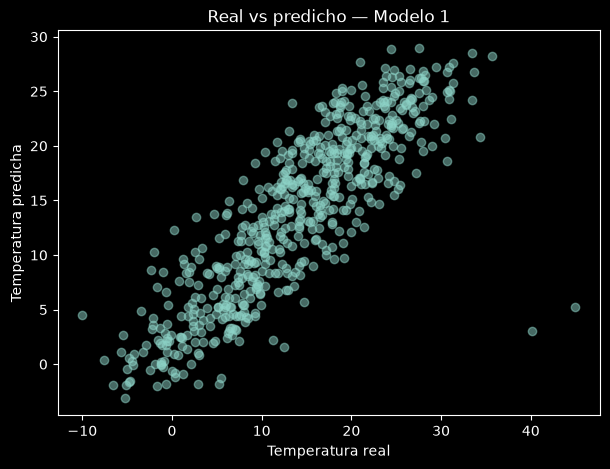

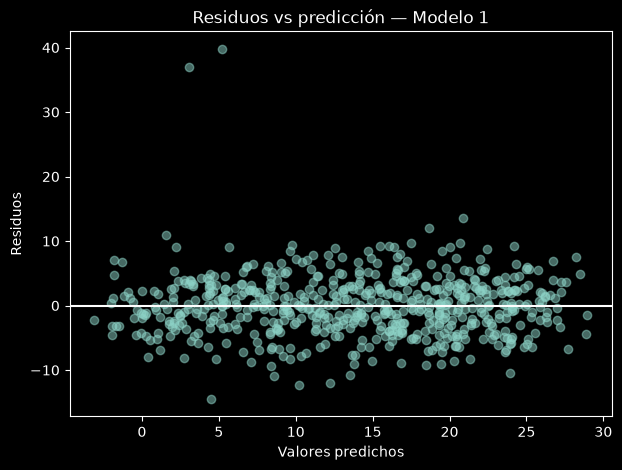

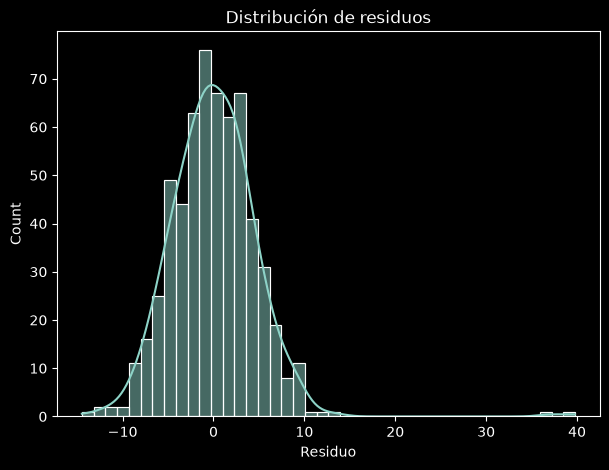

Autocorrelación de residuos a rezago 1: 0.25998484371478525


In [29]:
residuos = pd.Series(
    y_test.to_numpy() - y_pred_mejor,
    index=y_test.index
)

plt.figure(figsize=(7, 5))
plt.scatter(y_test, y_pred_mejor, alpha=0.5)
plt.xlabel("Temperatura real")
plt.ylabel("Temperatura predicha")
plt.title(f"Real vs predicho — {mejor_nombre}")
plt.show()

plt.figure(figsize=(7, 5))
plt.scatter(y_pred_mejor, residuos, alpha=0.5)
plt.axhline(y=0)
plt.xlabel("Valores predichos")
plt.ylabel("Residuos")
plt.title(f"Residuos vs predicción — {mejor_nombre}")
plt.show()

plt.figure(figsize=(7, 5))
sns.histplot(residuos, kde=True)
plt.xlabel("Residuo")
plt.title("Distribución de residuos")
plt.show()

autocorrelacion = residuos.sort_index().autocorr(lag=1)
print("Autocorrelación de residuos a rezago 1:", autocorrelacion)


In [30]:
# Resumen numérico de los residuos
media_residuos = residuos.mean()
mediana_residuos = residuos.median()
desv_residuos = residuos.std()
asimetria_residuos = residuos.skew()

print("Media de residuos:", media_residuos)
print("Mediana de residuos:", mediana_residuos)
print("Desviación estándar:", desv_residuos)
print("Asimetría:", asimetria_residuos)
print("Autocorrelación lag 1:", autocorrelacion)

if abs(autocorrelacion) < 0.20:
    print("Independencia temporal: no se observa una autocorrelación fuerte.")
elif abs(autocorrelacion) < 0.40:
    print("Independencia temporal: se observa una dependencia temporal leve/moderada.")
else:
    print("Independencia temporal: se observa una dependencia temporal importante.")


Media de residuos: 0.0344962074002926
Mediana de residuos: -0.07574021874318593
Desviación estándar: 4.790630950192842
Asimetría: 1.6500243356280222
Autocorrelación lag 1: 0.25998484371478525
Independencia temporal: se observa una dependencia temporal leve/moderada.


### Validación de supuestos

Los gráficos y estadísticas anteriores se utilizan para revisar los supuestos principales de la regresión lineal:

- **Linealidad:** la nube de valores reales frente a predichos presenta una tendencia aproximadamente lineal, aunque existen observaciones alejadas del patrón principal.
- **Homoscedasticidad:** los residuos se concentran alrededor de cero y no muestran un patrón perfectamente definido. Sin embargo, existen algunos errores de gran magnitud, por lo que el supuesto no puede considerarse perfecto.
- **Normalidad de residuos:** la mayor parte de los residuos presenta una distribución aproximadamente centrada en cero, pero se observan valores extremos positivos y negativos. Esto produce colas y hace que la normalidad sea solo aproximada.
- **Independencia:** se calcula la autocorrelación de los residuos ordenados por su índice original. En la ejecución actual se obtuvo una autocorrelación positiva moderada, por lo que puede existir cierta dependencia temporal. Esto es razonable en datos meteorológicos y debe mencionarse como una limitación del split aleatorio.
- **Multicolinealidad:** varias variables meteorológicas contienen información relacionada entre sí, por ejemplo presión media/mínima/máxima, humedad media/mínima/máxima y variables temporales derivadas de la fecha. Por esto, los coeficientes individuales deben interpretarse con cautela.

En consecuencia, el modelo puede ser útil para predicción, pero los supuestos de la regresión lineal se cumplen de manera aproximada y no perfecta.


In [31]:
# Revisión sencilla de multicolinealidad entre variables numéricas
corr = X_train_base.select_dtypes(include="number").corr().abs()

pares_correlacionados = []

columnas_corr = corr.columns

for i in range(len(columnas_corr)):
    for j in range(i + 1, len(columnas_corr)):
        valor = corr.iloc[i, j]

        if valor >= 0.80:
            pares_correlacionados.append({
                "Variable 1": columnas_corr[i],
                "Variable 2": columnas_corr[j],
                "Correlación absoluta": valor
            })

tabla_correlaciones_altas = pd.DataFrame(pares_correlacionados)

if len(tabla_correlaciones_altas) > 0:
    tabla_correlaciones_altas = tabla_correlaciones_altas.sort_values(
        "Correlación absoluta",
        ascending=False
    )
    display(tabla_correlaciones_altas)
else:
    print("No se encontraron pares de variables numéricas con correlación absoluta >= 0.80.")


,Variable 1,Variable 2,Correlación absoluta
4,viento_desv,rafaga_desv,0.999996
6,rafaga_desv,viento_norte,0.998910
1,presion_media,presion_max,0.961159
0,presion_media,presion_min,0.955655
5,viento_desv,viento_norte,0.904975
2,presion_min,presion_max,0.841636
3,viento_media,viento_max,0.835973


## 9. Coeficientes e importancia de variables del mejor modelo

Se reportan los coeficientes del modelo para interpretar el signo de las relaciones. **La magnitud bruta de los coeficientes no debe utilizarse por sí sola como ranking de importancia**, porque depende del escalamiento y puede verse afectada por multicolinealidad.

Por esa razón, además se calcula **Permutation Importance** sobre el conjunto de test, que permite estimar cuánto empeora el modelo cuando se altera una variable original.


In [32]:
nombres_transformados = mejor_modelo.named_steps[
    "preprocesamiento"
].get_feature_names_out()

coeficientes = mejor_modelo.named_steps[
    "regresion"
].coef_

tabla_coeficientes = pd.DataFrame({
    "Variable_transformada": nombres_transformados,
    "Coeficiente": coeficientes
})

tabla_coeficientes["Magnitud"] = (
    tabla_coeficientes["Coeficiente"].abs()
)

tabla_coeficientes = tabla_coeficientes.sort_values(
    "Magnitud",
    ascending=False
)

display(tabla_coeficientes)


,Variable_transformada,Coeficiente,Magnitud
16,numericas__viento_norte,-1436.140646,1436.140646
15,numericas__rafaga_desv,-1431.621453,1431.621453
24,categoricas__estacion_anio_verano,9.478683,9.478683
28,categoricas__mes_january,-8.116136,8.116136
1,numericas__presion_min,-7.962353,7.962353
0,numericas__presion_media,7.596819,7.596819
27,categoricas__mes_february,-6.891692,6.891692
19,numericas__registros_del_dia,6.293098,6.293098
31,categoricas__mes_march,-6.123497,6.123497
35,categoricas__mes_september,5.442394,5.442394


In [33]:
# Importancia por variable original mediante permutación sobre el conjunto test.
# Esta medida es útil porque no depende directamente de la escala del coeficiente.

perm = permutation_importance(
    mejor_modelo,
    X_test_mejor,
    y_test,
    scoring="neg_mean_squared_error",
    n_repeats=10,
    random_state=42
)

tabla_importancia = pd.DataFrame({
    "Variable": X_test_mejor.columns,
    "Importancia_promedio": perm.importances_mean,
    "Desviacion": perm.importances_std
}).sort_values(
    "Importancia_promedio",
    ascending=False
)

display(tabla_importancia)


,Variable,Importancia_promedio,Desviacion
23,mes,38.087232,2.189362
22,estacion_anio,20.786162,1.909172
16,viento_norte,5.671642,0.795171
21,dia_del_anio,3.766576,0.423386
0,presion_media,1.873233,0.207860
7,humedad_desv,1.766954,0.208812
20,anio,1.041375,0.247376
24,sector_viento,0.705003,0.229571
1,presion_min,0.604213,0.191025
3,presion_desv,0.441453,0.145241


## 10. Análisis de resultados

### 10.1 ¿Cuál fue el valor de los diferentes coeficientes obtenidos en el mejor modelo?

La tabla `tabla_coeficientes` contiene el coeficiente asociado a cada variable después de la transformación. Un coeficiente positivo indica que, manteniendo las demás variables constantes, un aumento de esa variable se asocia con un aumento de la temperatura máxima predicha; un coeficiente negativo indica la relación contraria.

Para variables categóricas codificadas con One Hot Encoding, el coeficiente se interpreta respecto a la categoría de referencia que fue eliminada con `drop="first"`.

No debe concluirse causalidad a partir de estos coeficientes. Además, la correlación entre variables meteorológicas puede afectar la estabilidad de sus valores individuales.

### 10.2 ¿Cuál modelo ofrece mejor rendimiento?

El mejor modelo es el que aparece en la primera fila de la tabla `resultados`, debido a que presenta el **menor RMSE** sobre el mismo conjunto test. Como apoyo, también se consideran menor MAE y mayor R².

El RMSE expresa el error típico dando mayor peso a errores grandes; el MAE representa el error absoluto promedio y R² representa la proporción de variabilidad de `temp_max_manana` explicada por el modelo.

### 10.3 ¿Cuáles variables fueron seleccionadas y qué interpretación tienen?

No se realizó una selección automática que eliminara predictores: los modelos conservaron las variables meteorológicas disponibles después de la limpieza. La tabla `tabla_importancia` permite ordenarlas según cuánto empeora el desempeño al alterar cada variable.

Las variables con mayor importancia son las que más información aportan a la predicción. Este conocimiento puede orientar el monitoreo de los sensores más relevantes y ayudar a priorizar variables meteorológicas asociadas con jornadas de mayor temperatura y, por extensión, con condiciones que podrían favorecer riesgos como incendios.

### 10.4 Representación matemática de la regresión lineal

La regresión lineal múltiple utilizada puede representarse como:

\[
\hat{y} = \beta_0 + \beta_1x_1 + \beta_2x_2 + \cdots + \beta_px_p
\]

donde \(\hat{y}\) es la predicción de `temp_max_manana`, \(\beta_0\) es el intercepto, \(x_j\) son los predictores y \(\beta_j\) sus coeficientes.

El método utilizado es **mínimos cuadrados ordinarios (OLS)**. Los coeficientes se escogen buscando minimizar:

\[
\sum_{i=1}^{n}(y_i-\hat{y}_i)^2
\]

Matricialmente, cuando la inversa existe, la solución se expresa como:

\[
\hat{\beta} = (X^TX)^{-1}X^Ty
\]

En la práctica, `LinearRegression` de scikit-learn utiliza métodos numéricos estables para obtener la solución.

### 10.5 Dos tipos de sesgo que pueden afectar los resultados

**Sesgo de medición:** los datos contienen inconsistencias de unidades, categorías mal escritas, valores imposibles y posibles errores de sensores. Si estos errores no se corrigen de forma adecuada, el modelo aprende relaciones que no corresponden al fenómeno meteorológico real.

**Sesgo temporal o de representación:** los datos etiquetados corresponden a ciertos años y condiciones meteorológicas, mientras que el modelo se aplica posteriormente a un periodo futuro. Si cambian las condiciones climáticas o la distribución de las variables, el conjunto de entrenamiento podría no representar completamente el escenario futuro. Además, un split aleatorio mezcla observaciones de distintos momentos y puede producir una estimación más optimista que una validación estrictamente temporal.


## 11. Entrenamiento final y predicción del conjunto no etiquetado

Después de seleccionar el mejor modelo con el conjunto de validación, se vuelve a entrenar la estrategia ganadora utilizando todos los datos etiquetados disponibles. El conjunto de prueba no etiquetado recibe exactamente la misma limpieza y transformaciones.


In [34]:
X_total = X.copy()
y_total = y.copy()

X_prueba_final = df_prueba_limpio.reindex(columns=X_total.columns).copy()

if mejor_nombre == "Modelo 1":
    modelo_final = clone(modelo_1)
    modelo_final.fit(X_total, y_total)

else:
    # Para Modelo 2 los límites IQR finales se calculan únicamente con
    # todos los datos etiquetados y luego se aplican al test no etiquetado.
    X_total_robusto = X_total.copy()
    X_prueba_robusto = X_prueba_final.copy()

    columnas_iqr_final = X_total_robusto.select_dtypes(
        include="number"
    ).columns.tolist()

    columnas_iqr_final = [
        columna for columna in columnas_iqr_final
        if columna not in columnas_excluir_iqr
    ]

    limites_finales = {}

    for columna in columnas_iqr_final:
        q1 = X_total_robusto[columna].quantile(0.25)
        q3 = X_total_robusto[columna].quantile(0.75)
        iqr = q3 - q1

        inferior = q1 - 3 * iqr
        superior = q3 + 3 * iqr

        limites_finales[columna] = (inferior, superior)

        mascara_total = (
            (X_total_robusto[columna] < inferior) |
            (X_total_robusto[columna] > superior)
        )

        X_total_robusto.loc[
            mascara_total,
            columna
        ] = float("nan")

        mascara_prueba = (
            (X_prueba_robusto[columna] < inferior) |
            (X_prueba_robusto[columna] > superior)
        )

        X_prueba_robusto.loc[
            mascara_prueba,
            columna
        ] = float("nan")

    modelo_final = clone(modelo_2)
    modelo_final.fit(X_total_robusto, y_total)
    X_prueba_final = X_prueba_robusto

predicciones_finales = modelo_final.predict(X_prueba_final)

print("Número de predicciones:", len(predicciones_finales))
print(predicciones_finales[:10])


Número de predicciones: 364
[ 4.93118469  2.13840521  5.0252503   4.97232372 -0.18730254 -1.61164785
  2.89740982  5.68324928  4.11906236  4.86424421]


In [35]:
# El archivo se exporta usando como base el mismo conjunto no etiquetado.
salida = df_prueba.copy()
salida["temp_max_manana"] = predicciones_finales

salida.to_csv(
    "Datos Test Lab 1.csv",
    index=False
)

display(salida.head())
print("Archivo generado: Datos Test Lab 1.csv")


,fecha,presion_media,presion_min,presion_max,presion_desv,humedad_media,humedad_min,humedad_max,humedad_desv,viento_media,...,viento_norte,viento_este,direccion_viento,registros_del_dia,anio,dia_del_anio,estacion_anio,mes,sector_viento,temp_max_manana
0,01.01.2016,998.9860,995.57,1000.60,1.1082,96.1493,90.8,98.7,2.0034,0.9649,...,-0.8328,0.0927,173.6501,144,2016,1,invierno,January,S,4.931185
1,02.01.2016,991.4241,989.27,995.51,1.9413,92.3236,85.8,96.8,2.6562,1.9886,...,1.1161,0.6688,30.9301,144,2016,2,invierno,January,NE,2.138405
2,03.01.2016,984.0232,974.12,989.39,4.5841,83.6056,73.9,94.7,6.9967,2.4992,...,-0.7923,1.2638,122.0847,144,2016,3,invierno,January,SE,5.025250
3,04.01.2016,968.2449,966.52,974.02,1.9034,85.4688,75.5,93.8,5.8148,2.0932,...,-1.6217,0.7020,156.5944,144,2016,4,invierno,January,SE,4.972324
4,05.01.2016,970.0099,967.85,972.90,1.6668,94.3521,92.0,96.8,1.4253,1.8380,...,1.6549,0.7109,23.2458,144,2016,5,invierno,January,NE,-0.187303


Archivo generado: Datos Test Lab 1.csv


In [36]:
# Verificación final del archivo de entrega
print("Filas del archivo original de prueba:", len(df_prueba))
print("Filas del archivo de salida:", len(salida))
print("Predicciones nulas:", salida["temp_max_manana"].isnull().sum())
print("Predicción mínima:", salida["temp_max_manana"].min())
print("Predicción máxima:", salida["temp_max_manana"].max())

assert len(salida) == len(df_prueba), "El número de filas del archivo final no coincide con el test."
assert salida["temp_max_manana"].isnull().sum() == 0, "Existen predicciones nulas."

print("Verificación final correcta.")


Filas del archivo original de prueba: 364
Filas del archivo de salida: 364
Predicciones nulas: 0
Predicción mínima: -1.6116478488436314
Predicción máxima: 29.476906434260854
Verificación final correcta.


## 12. Conclusiones

Se construyeron dos modelos de regresión lineal con estrategias de preparación distintas y se evaluaron sobre el mismo 25% de test con semilla 42. La selección final se realizó mediante RMSE, complementando el análisis con MAE y R².

La estrategia robusta incorpora detección de valores atípicos en los predictores, mientras que la estrategia base conserva los datos después de la limpieza determinística y utiliza escalamiento Min-Max. La comparación permite cuantificar si el tratamiento adicional de atípicos aporta una mejora real en datos no vistos.

La interpretación de coeficientes e importancia permite identificar qué variables meteorológicas aportan mayor información predictiva. Sin embargo, la existencia de correlaciones entre variables y residuos extremos obliga a interpretar los coeficientes con cautela y evita atribuir relaciones causales.

Finalmente, el modelo seleccionado se reentrena con todos los datos etiquetados y se utiliza para generar la etiqueta `temp_max_manana` sobre el archivo no etiquetado.


In [37]:
print("CONCLUSIÓN CUANTITATIVA")
print("----------------------")
print(
    f"Se seleccionó {mejor_nombre} porque obtuvo el menor RMSE "
    f"({resultados.iloc[0]['RMSE']:.3f}) en el mismo conjunto de test."
)
print(
    f"Su MAE fue {resultados.iloc[0]['MAE']:.3f} y su R² fue "
    f"{resultados.iloc[0]['R2']:.3f}."
)
print(
    "La elección se realizó usando datos no vistos durante el entrenamiento, "
    "por lo que la comparación es más válida que evaluar sobre los mismos "
    "datos usados para ajustar el modelo."
)


CONCLUSIÓN CUANTITATIVA
----------------------
Se seleccionó Modelo 1 porque obtuvo el menor RMSE (4.787) en el mismo conjunto de test.
Su MAE fue 3.508 y su R² fue 0.722.
La elección se realizó usando datos no vistos durante el entrenamiento, por lo que la comparación es más válida que evaluar sobre los mismos datos usados para ajustar el modelo.


## 13. Uso de herramientas de IA generativa

### Declaración del uso

Se utilizó **ChatGPT** como herramienta de apoyo para aclarar conceptos, depurar código, revisar el flujo de preparación de datos y mejorar la redacción técnica del notebook. La herramienta no sustituyó la ejecución ni la revisión de los resultados por parte de los estudiantes.

### Prompts principales utilizados

Entre las consultas principales se incluyeron:

- Explicación de la métrica RMSE y de la diferencia entre datos etiquetados y no etiquetados.
- Cómo identificar e imputar valores nulos con mediana y moda.
- Explicación detallada de `OneHotEncoder`, `ColumnTransformer` y `Pipeline`.
- Revisión de inconsistencias categóricas como meses abreviados, mayúsculas/minúsculas y sectores del viento.
- Depuración de errores producidos por `pd.NA` y `SimpleImputer`.
- Propuesta de tratamiento de valores atípicos con IQR sin eliminar filas completas.
- Revisión de la comparación de los dos modelos y de los elementos faltantes según la rúbrica.

### Análisis crítico del resultado

Las explicaciones sobre pipelines, imputación y métricas fueron útiles para organizar el flujo del modelo. Durante el proceso se detectaron y corrigieron decisiones iniciales que podían generar problemas metodológicos. Por ejemplo, la imputación de predictores se trasladó al pipeline después del `train_test_split` para evitar fuga de información, y la variable objetivo dejó de imputarse porque una etiqueta artificial alteraría el aprendizaje.

También se corrigió la evaluación del Modelo 1: originalmente sus métricas se calculaban sobre los mismos datos utilizados para entrenarlo y algunas transformaciones se ajustaban nuevamente sobre el conjunto de prueba. Para hacer una comparación válida, ambos modelos se reimplementaron sobre el mismo split 75/25 y las transformaciones se ajustaron únicamente con entrenamiento.

### Aportes propios de los estudiantes

Los estudiantes realizaron la exploración, ejecutaron y verificaron el código, tomaron decisiones sobre las estrategias de preparación, analizaron los resultados obtenidos y distribuyeron la construcción de las dos alternativas de regresión lineal. Las recomendaciones de IA fueron revisadas, modificadas e integradas solo cuando resultaban coherentes con el ciclo de machine learning visto en el curso.
